As Logistic Regression is mainly used for classification problems, it can't be used to predict exact stock prices.

We can instead try to reframe it into a classification problem. Where depending on different variables each day we classify the stock market price as up or down (binary classification).

We will measure the 10-days moving average, correlation, RSI, and the open and close prices per day of a stock as the attributes to measure stock price fluctuations.

# Library Import


In [39]:
!pip install talib-binary

     |████████████████████████████████| 2.4 MB 24.4 MB/s 


In [84]:
#Necessary Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os #accessing directory structure
import talib as ta

#Logistic Regression
from sklearn.metrics import accuracy_score  
from sklearn.linear_model import LogisticRegression  
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [85]:
#Run this if your data is in google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Cleaning and Setup


In [86]:
#Load Dataset
def loadData(fileLocation):
    df = pd.read_csv(fileLocation, delimiter = ',')
    df.columns=['Date','Open','High','Low','Close','Volume','OpenInt']
    df.drop('OpenInt', axis='columns', inplace=True)
    newdf=df[['Date','Open','High','Low','Volume','Close']]
    return df

In [87]:
#Open dataset
#df=loadData("/content/drive/MyDrive/Colab Notebooks/AI_Group/ArtificialIntelligence_UbiquantMarketPrediction/Data/ETFs/aadr.us.txt")
df=loadData("Data/ETFs/aadr.us.txt")
print(df.shape)
df['Date']=pd.to_datetime(df.Date,format="%Y-%m-%d")
df=df.set_index('Date')
df.head()

(1565, 6)


,Open,High,Low,Close,Volume
Date,,,,,
2010-07-21,24.333,24.333,23.946,23.946,43321
2010-07-22,24.644,24.644,24.362,24.487,18031
2010-07-23,24.759,24.759,24.314,24.507,8897
2010-07-26,24.624,24.624,24.449,24.595,19443
2010-07-27,24.477,24.517,24.431,24.517,8456


In [88]:
#Calculating attributes, this is our x
df['S_10'] = df['Close'].rolling(window=10).mean()
df['Corr'] = df['Close'].rolling(window=10).corr(df['S_10'])
df['RSI'] = ta.RSI(np.array(df['Close']), timeperiod =10)
df['Open-Close'] = df['Open'] - df['Close'].shift(1)
df['Open-Open'] = df['Open'] - df['Open'].shift(1)
df = df.dropna()
x = df.iloc[:,:9]
x.head()

,Open,High,Low,Close,Volume,S_10,Corr,RSI,Open-Close
Date,,,,,,,,,
2010-08-16,24.507,24.507,24.467,24.467,3094,24.8250,-0.513644,51.249287,0.106
2010-08-17,24.789,24.966,24.789,24.966,6704,24.8174,-0.517705,61.674651,0.322
2010-08-18,25.013,25.109,25.013,25.109,587,24.8214,-0.470713,64.117971,0.047
2010-08-19,24.966,24.966,24.966,24.966,513,24.8062,-0.426172,59.876577,-0.143
2010-08-20,24.537,24.537,24.517,24.527,1238,24.7663,-0.321608,48.853342,-0.429


In [89]:
#Calculating result value, this is our Y (Stock market going up or down)
# -1 = Stock Price going down
# 1 = Stock Price going up
y = np.where(df['Close'].shift(-1) > df['Close'],1,-1)
y[:5]

array([ 1,  1, -1, -1,  1])

In [90]:
#Data Splitting 70-30 split
split = int(0.7*len(df))
x_train, x_test, y_train, y_test = x[:split], x[split:], y[:split], y[split:]
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1082, 9), (465, 9), (1082,), (465,))

# Model

In [91]:
#Model Creation
model = LogisticRegression()
model = model.fit(x_train,y_train)

[[0.44475786 0.55524214]
 [0.45150595 0.54849405]
 [0.52794    0.47206   ]
 [0.53216546 0.46783454]
 [0.42397115 0.57602885]]


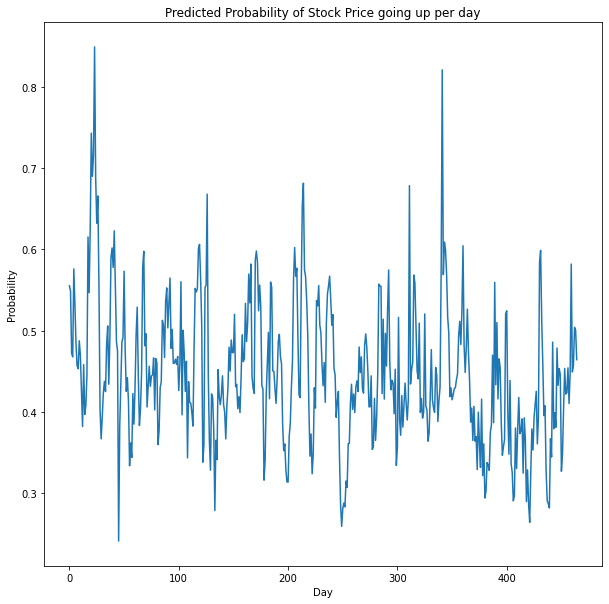

In [110]:
#Prints the calculated probability of stock price going up or down
probability = model.predict_proba(x_test)
print(probability[0:5]) #probability for first 5 days
plt.figure(figsize=(10,10))
plt.plot(probability[:,1])
plt.title('Predicted Probability of Stock Price going up per day')
plt.ylabel('Probability')
plt.xlabel('Day')
plt.show()

In [98]:
#Predict stock price trend
#-1 Down
# 1 Up
predicted = model.predict(x_test)
predicted[0:5]

array([ 1,  1, -1, -1,  1])

# Evaluation

In [105]:
#Accuracy report
accuracy = accuracy_score(y_test,predicted)*100  
print ("Model Prediction Accuracy")  
print(accuracy) 

Model Prediction Accuracy
52.04301075268817


In [104]:
print(metrics.classification_report(y_test, predicted))

              precision    recall  f1-score   support

          -1       0.49      0.80      0.61       214
           1       0.62      0.28      0.39       251

    accuracy                           0.52       465
   macro avg       0.55      0.54      0.50       465
weighted avg       0.56      0.52      0.49       465

